# **Model Evaluation - Comprehensive Analysis**

This notebook performs detailed evaluation and analysis of trained models.

**Objectives:**
- Load and evaluate all models
- Generate comprehensive metrics
- Create visualizations
- Perform error analysis
- Generate business insights
- Export results for Tableau

In [1]:
import os
import time
import pickle
from datetime import datetime
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, abs as spark_abs, when, avg, count, stddev
from pyspark.ml.regression import (
    LinearRegressionModel, DecisionTreeRegressionModel,
    RandomForestRegressionModel, GBTRegressionModel
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidatorModel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## **1. Initialize Spark Session**

In [2]:
spark = SparkSession.builder \
    .appName("Model_Evaluation") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

log4j = spark.sparkContext._jvm.org.apache.log4j
log4j.LogManager.getLogger("org.apache.spark.storage.MemoryStore").setLevel(log4j.Level.ERROR)
log4j.LogManager.getLogger("org.apache.spark.storage.BlockManager").setLevel(log4j.Level.ERROR)
log4j.LogManager.getLogger("org.apache.spark.scheduler.DAGScheduler").setLevel(log4j.Level.ERROR)
print(f"Spark Version: {spark.version}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/27 13:59:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/27 13:59:47 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/02/27 13:59:47 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/02/27 13:59:47 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


Spark Version: 3.5.0


## **2. Load Data**

In [3]:
df = spark.read.parquet("../data/processed_features.parquet")

df = df.select("features", "label", "year", "property_type", "postcode_area", "district", "county")

test_data = df.filter(col("year") == 2023)
future_test = df.filter(col("year") >= 2024)

print(f"Test data: {test_data.count():,} records")
print(f"Future test: {future_test.count():,} records")

test_data.cache()
future_test.cache()

Test data: 856,811 records
Future test: 1,597,908 records


DataFrame[features: vector, label: int, year: int, property_type: string, postcode_area: string, district: string, county: string]

## **3. Load Trained Models**

In [4]:
lr_model = LinearRegressionModel.load("../data/models/linear_regression")
dt_model = DecisionTreeRegressionModel.load("../data/models/decision_tree")
rf_model = RandomForestRegressionModel.load("../data/models/random_forest")
gbt_model = GBTRegressionModel.load("../data/models/gradient_boosted_trees")
tuned_model = CrossValidatorModel.load("../data/models/tuned_random_forest").bestModel

print("All models loaded successfully")

All models loaded successfully


## **4. Generate Predictions**

In [5]:
models = {
    'Linear Regression': lr_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'GBT': gbt_model,
    'Tuned RF': tuned_model
}

predictions = {}
for name, model in models.items():
    predictions[name] = model.transform(test_data)
    print(f"{name} predictions generated")

Linear Regression predictions generated
Decision Tree predictions generated
Random Forest predictions generated
GBT predictions generated
Tuned RF predictions generated


## **5. Comprehensive Metrics**

In [6]:
evaluator_rmse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
evaluator_mse = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mse")

results = []

for name, pred in predictions.items():
    rmse = evaluator_rmse.evaluate(pred)
    r2 = evaluator_r2.evaluate(pred)
    mae = evaluator_mae.evaluate(pred)
    mse = evaluator_mse.evaluate(pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae,
        'MSE': mse,
        'MAPE': None
    })

results_df = pd.DataFrame(results)
print("\n=== Model Evaluation Metrics ===")
print(results_df.to_string(index=False))

26/02/27 14:00:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/02/27 14:00:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



=== Model Evaluation Metrics ===
            Model          RMSE       R2          MAE          MSE MAPE
Linear Regression 126072.820907 0.918453 50003.032929 1.589436e+10 None
    Decision Tree 121368.464826 0.924425 23977.052159 1.473030e+10 None
    Random Forest 102612.380020 0.945979 20003.071448 1.052930e+10 None
              GBT  98981.024417 0.949735 23584.738203 9.797243e+09 None
         Tuned RF 107918.627321 0.940247 17439.913703 1.164643e+10 None


## **6. Error Analysis**

In [7]:
best_predictions = predictions['Tuned RF']

error_analysis = best_predictions.withColumn(
    "absolute_error", spark_abs(col("label") - col("prediction"))
).withColumn(
    "percentage_error", spark_abs(col("label") - col("prediction")) / col("label") * 100
).withColumn(
    "error_category",
    when(spark_abs(col("label") - col("prediction")) < 50000, "Low")
    .when(spark_abs(col("label") - col("prediction")) < 100000, "Medium")
    .otherwise("High")
)

error_stats = error_analysis.select(
    avg("absolute_error").alias("mean_abs_error"),
    stddev("absolute_error").alias("std_abs_error"),
    avg("percentage_error").alias("mean_pct_error")
).collect()[0]

print(f"\nError Statistics:")
print(f"  Mean Absolute Error: £{error_stats['mean_abs_error']:,.2f}")
print(f"  Std Absolute Error: £{error_stats['std_abs_error']:,.2f}")
print(f"  Mean Percentage Error: {error_stats['mean_pct_error']:.2f}%")


Error Statistics:
  Mean Absolute Error: £17,439.91
  Std Absolute Error: £106,500.20
  Mean Percentage Error: 18.91%


In [8]:
error_by_category = error_analysis.groupBy("error_category").count().orderBy("count", ascending=False)
print("\nError Distribution by Category:")
error_by_category.show()


Error Distribution by Category:


+--------------+------+
|error_category| count|
+--------------+------+
|           Low|823200|
|          High| 18841|
|        Medium| 14770|
+--------------+------+



## **7. Performance by Property Type**

In [9]:
property_performance = error_analysis.groupBy("property_type").agg(
    count("*").alias("count"),
    avg("absolute_error").alias("avg_error"),
    avg("percentage_error").alias("avg_pct_error"),
    avg("label").alias("avg_actual_price"),
    avg("prediction").alias("avg_predicted_price")
).orderBy("property_type")

print("\nPerformance by Property Type:")
property_performance.show()


Performance by Property Type:


+-------------+------+------------------+------------------+------------------+-------------------+
|property_type| count|         avg_error|     avg_pct_error|  avg_actual_price|avg_predicted_price|
+-------------+------+------------------+------------------+------------------+-------------------+
|            D|187968|23100.581604967996|2.6270372315578774| 513186.4701066139|  508162.0932913148|
|            F|160557| 16886.00235726653|  4.14972781832136| 325340.5261371351|  316210.3437210943|
|            O| 50344| 80453.73301578248| 184.3803007756951| 647907.3822302559|   650118.324126325|
|            S|226851| 7717.026097626555| 22.97716319210465|310808.99776505283| 309501.96702625026|
|            T|231091| 9037.115570581851|2.3625923711500105| 280835.9181924004|  281600.6907577545|
+-------------+------+------------------+------------------+------------------+-------------------+



In [10]:
property_perf_pd = property_performance.toPandas()
property_perf_pd.to_csv("../tableau/performance_by_property_type.csv", index=False)
print("Property type performance exported")

Property type performance exported


## **8. Performance by Region**

In [11]:
region_performance = error_analysis.groupBy("postcode_area").agg(
    count("*").alias("count"),
    avg("absolute_error").alias("avg_error"),
    avg("percentage_error").alias("avg_pct_error")
).filter(col("count") > 100).orderBy("avg_error", ascending=False).limit(20)

print("\nTop 20 Areas by Prediction Error:")
region_performance.show()


Top 20 Areas by Prediction Error:


+-------------+-----+------------------+------------------+
|postcode_area|count|         avg_error|     avg_pct_error|
+-------------+-----+------------------+------------------+
|           W8|  291| 538158.6179235283|22.190571531913537|
|           WC|  455|246322.24089714888| 17.19082551768489|
|           W1| 2747|218186.55546758845| 68.24152107051654|
|           N6|  270| 218058.6317303492|18.333956516339427|
|           W2|  629| 210084.9795271014| 11.97296808985637|
|           EC|  819| 195391.0541586865| 25.58862727281622|
|         NULL| 2193|119404.61093749713|324.20906408166957|
|           N5|  314| 101294.5605187384|10.169438971388912|
|           W4|  671| 98514.96350808897| 35.01370764433904|
|           NW| 5546| 83546.81678926041|12.810850467592886|
|           SW|13914| 74347.84329385431|25.311256291019912|
|           W6|  546|  67931.7222316748| 7.113580844410168|
|           N2| 1193|  67397.0478109004| 65.47638989955279|
|           N7|  464|63971.559620681684|

In [12]:
region_perf_pd = region_performance.toPandas()
region_perf_pd.to_csv("../tableau/performance_by_region.csv", index=False)
print("Regional performance exported")

Regional performance exported


## **9. Feature Importance Analysis**

In [13]:
rf_importance = rf_model.featureImportances.toArray()
tuned_importance = tuned_model.featureImportances.toArray()

feature_names = [
    "year", "month", "quarter", "day_of_week", "is_weekend", "days_since_2019",
    "has_locality", "has_street",
    "area_avg_price", "area_transaction_count", "area_price_stddev",
    "district_avg_price", "district_transaction_count",
    "property_year_avg_price",
    "price_vs_area_avg", "price_vs_district_avg", "price_vs_property_avg"
]

importance_data = []
for i, name in enumerate(feature_names):
    if i < len(tuned_importance):
        importance_data.append({
            'Feature': name,
            'Importance': tuned_importance[i]
        })

importance_df = pd.DataFrame(importance_data).sort_values('Importance', ascending=False)

print("\nTop 10 Important Features:")
print(importance_df.head(10).to_string(index=False))


Top 10 Important Features:
                   Feature  Importance
     price_vs_property_avg    0.330219
     price_vs_district_avg    0.204306
         price_vs_area_avg    0.187955
   property_year_avg_price    0.078165
        district_avg_price    0.057323
            area_avg_price    0.053303
         area_price_stddev    0.011706
    area_transaction_count    0.003431
district_transaction_count    0.002442
           days_since_2019    0.001173


In [14]:
importance_df.to_csv("../tableau/feature_importance.csv", index=False)
print("Feature importance exported")

Feature importance exported


## **10. Residual Analysis**

In [15]:
residuals = best_predictions.withColumn(
    "residual", col("label") - col("prediction")
).select("label", "prediction", "residual").sample(False, 0.01, seed=42).toPandas()

print(f"Residual sample size: {len(residuals)}")
print(f"\nResidual Statistics:")
print(f"  Mean: £{residuals['residual'].mean():,.2f}")
print(f"  Std: £{residuals['residual'].std():,.2f}")
print(f"  Median: £{residuals['residual'].median():,.2f}")

Residual sample size: 8691

Residual Statistics:
  Mean: £1,016.60
  Std: £95,325.89
  Median: £1,420.51


## **11. Visualizations**

Evaluation plots saved


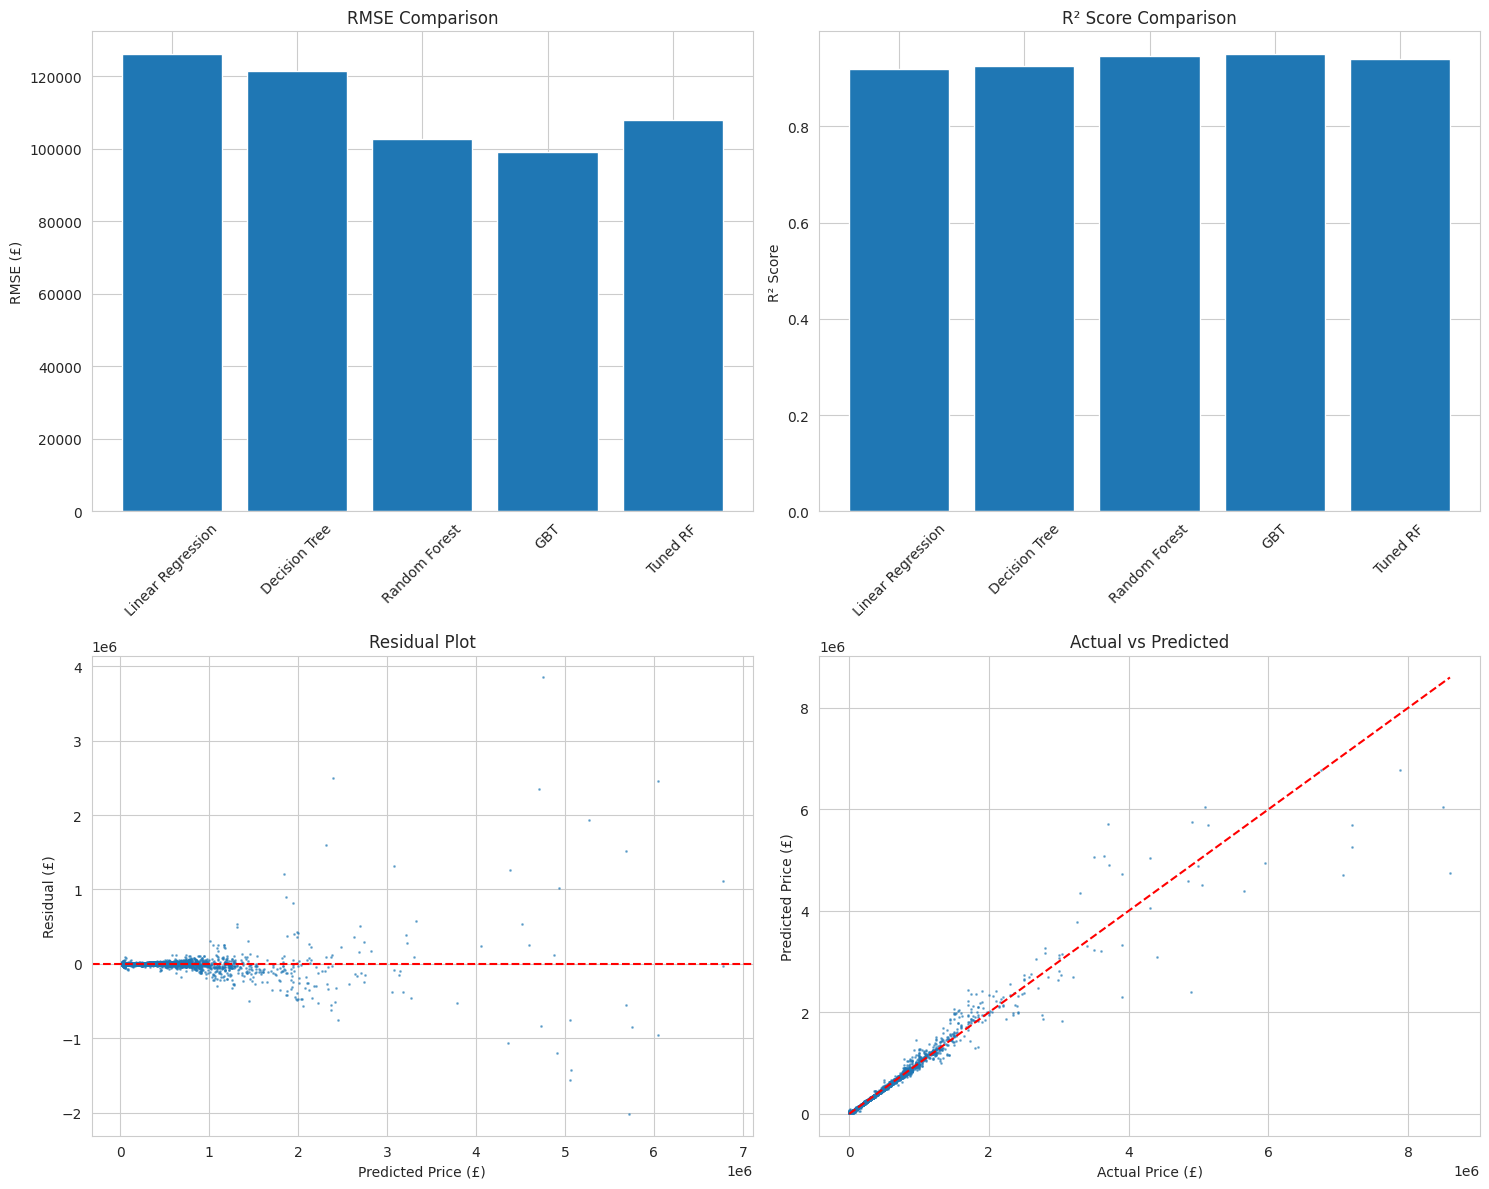

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

axes[0, 0].bar(results_df['Model'], results_df['RMSE'])
axes[0, 0].set_title('RMSE Comparison')
axes[0, 0].set_ylabel('RMSE (£)')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].bar(results_df['Model'], results_df['R2'])
axes[0, 1].set_title('R² Score Comparison')
axes[0, 1].set_ylabel('R² Score')
axes[0, 1].tick_params(axis='x', rotation=45)

axes[1, 0].scatter(residuals['prediction'], residuals['residual'], alpha=0.5, s=1)
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_title('Residual Plot')
axes[1, 0].set_xlabel('Predicted Price (£)')
axes[1, 0].set_ylabel('Residual (£)')

axes[1, 1].scatter(residuals['label'], residuals['prediction'], alpha=0.5, s=1)
axes[1, 1].plot([residuals['label'].min(), residuals['label'].max()], 
                [residuals['label'].min(), residuals['label'].max()], 'r--')
axes[1, 1].set_title('Actual vs Predicted')
axes[1, 1].set_xlabel('Actual Price (£)')
axes[1, 1].set_ylabel('Predicted Price (£)')

plt.tight_layout()
plt.savefig('../tableau/model_evaluation_plots.png', dpi=300, bbox_inches='tight')
print("Evaluation plots saved")
plt.show()

Feature importance plot saved


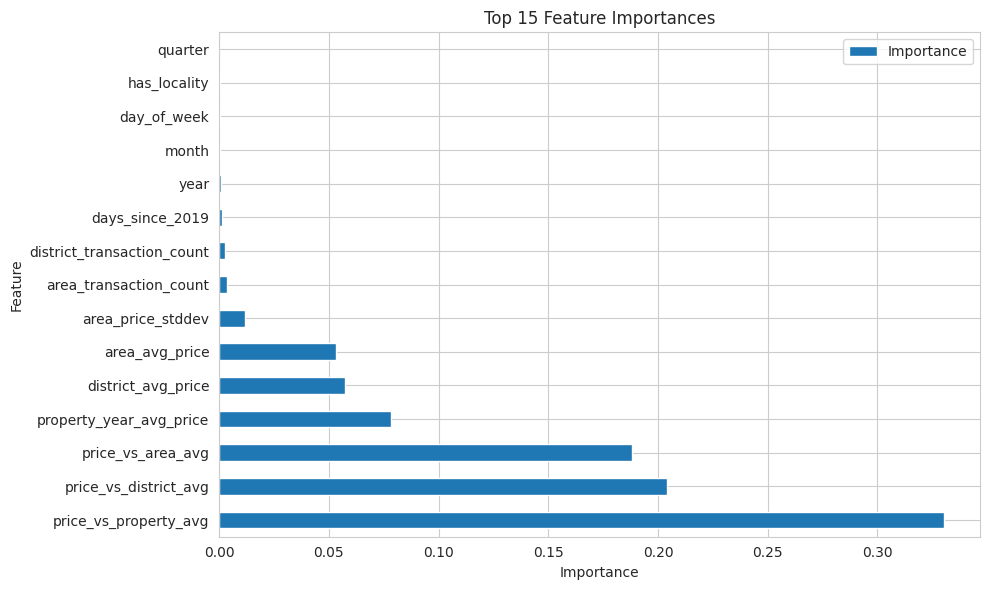

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
importance_df.head(15).plot(x='Feature', y='Importance', kind='barh', ax=ax)
ax.set_title('Top 15 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../tableau/feature_importance_plot.png', dpi=300, bbox_inches='tight')
print("Feature importance plot saved")
plt.show()

## **12. Statistical Significance Testing**

In [18]:
sample_size = 10000

pred_rf = predictions['Random Forest'].select("label", "prediction").limit(sample_size).toPandas()
pred_tuned = predictions['Tuned RF'].select("label", "prediction").limit(sample_size).toPandas()

errors_rf = np.abs(pred_rf['label'] - pred_rf['prediction'])
errors_tuned = np.abs(pred_tuned['label'] - pred_tuned['prediction'])

t_stat, p_value = stats.ttest_rel(errors_rf, errors_tuned)

print(f"\nStatistical Significance Test (RF vs Tuned RF):")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.4f}")
print(f"  Significant at α=0.05: {p_value < 0.05}")


Statistical Significance Test (RF vs Tuned RF):
  t-statistic: 6.9562
  p-value: 0.0000
  Significant at α=0.05: True


## **13. Business Insights**

In [19]:
price_ranges = error_analysis.withColumn(
    "price_range",
    when(col("label") < 200000, "<200k")
    .when(col("label") < 400000, "200k-400k")
    .when(col("label") < 600000, "400k-600k")
    .when(col("label") < 1000000, "600k-1M")
    .otherwise(">1M")
)

price_range_perf = price_ranges.groupBy("price_range").agg(
    count("*").alias("count"),
    avg("percentage_error").alias("avg_pct_error"),
    avg("absolute_error").alias("avg_abs_error")
).orderBy("price_range")

print("\nPerformance by Price Range:")
price_range_perf.show()


Performance by Price Range:


+-----------+------+------------------+------------------+
|price_range| count|     avg_pct_error|     avg_abs_error|
+-----------+------+------------------+------------------+
|  200k-400k|349787|1.7985769254352761| 5120.620687043636|
|  400k-600k|136671|2.3066789808504176|11167.412441613349|
|    600k-1M| 72088| 3.593413317155025| 27909.68862784115|
|      <200k|265439|  55.2230073634089| 4304.165969131558|
|        >1M| 32826|10.330778836928504|258053.82262803862|
+-----------+------+------------------+------------------+



In [20]:
price_range_pd = price_range_perf.toPandas()
price_range_pd.to_csv("../tableau/performance_by_price_range.csv", index=False)
print("Price range performance exported")

Price range performance exported


## **14. Model Recommendation**

In [21]:
best_model_name = results_df.loc[results_df['R2'].idxmax(), 'Model']
best_r2 = results_df['R2'].max()
best_rmse = results_df.loc[results_df['R2'].idxmax(), 'RMSE']

print(f"\n{'='*50}")
print(f"RECOMMENDED MODEL: {best_model_name}")
print(f"{'='*50}")
print(f"  R² Score: {best_r2:.4f}")
print(f"  RMSE: £{best_rmse:,.2f}")
print(f"  Explains {best_r2*100:.2f}% of price variance")
print(f"{'='*50}")


RECOMMENDED MODEL: GBT
  R² Score: 0.9497
  RMSE: £98,981.02
  Explains 94.97% of price variance


## **15. Export Final Results**

In [22]:
results_df.to_csv("../data/final_model_results.csv", index=False)
results_df.to_csv("../tableau/final_model_results.csv", index=False)

print("Final results exported")

Final results exported


In [23]:
predictions_export = error_analysis.select(
    "label", "prediction", "absolute_error", "percentage_error",
    "property_type", "postcode_area", "year"
).sample(False, 0.01, seed=42).toPandas()

predictions_export.to_csv("../tableau/detailed_predictions.csv", index=False)
print("Detailed predictions exported")

Detailed predictions exported


In [24]:
summary = {
    'Total_Test_Records': test_data.count(),
    'Best_Model': best_model_name,
    'Best_R2': best_r2,
    'Best_RMSE': best_rmse,
    'Mean_Absolute_Error': error_stats['mean_abs_error'],
    'Mean_Percentage_Error': error_stats['mean_pct_error'],
    'Evaluation_Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv("../tableau/evaluation_summary.csv", index=False)
print("\nEvaluation summary exported")


Evaluation summary exported
